# Importuri

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


# Incarcarea datelor

In [2]:
df = pd.read_csv("../data/products.csv")

# Eliminam spatiile din numele coloanelor
df.columns = df.columns.str.strip()

df.head()


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


# Informatii generale despre dataset

In [3]:
df.info()
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  str    
 2   Merchant ID      35311 non-null  int64  
 3   Category Label   35267 non-null  str    
 4   _Product Code    35216 non-null  str    
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7   Listing Date     35252 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 2.2 MB


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
count,35311.000000,35139,35311.000000,35267,35216,35297.000000,35141.000000,35252
unique,NaN,30860,NaN,13,35216,NaN,NaN,1096
top,NaN,washing machine,NaN,Fridge Freezers,QA-2276-XC,NaN,NaN,8/5/2024
freq,NaN,90,NaN,5495,1,NaN,NaN,53
mean,26150.800176,NaN,120.501883,NaN,NaN,2501.469587,2.998261,NaN
std,13498.191220,NaN,117.045557,NaN,NaN,1438.217697,1.152664,NaN
min,1.000000,NaN,1.000000,NaN,NaN,0.000000,1.000000,NaN
25%,14958.500000,NaN,17.000000,NaN,NaN,1256.000000,2.000000,NaN
50%,27614.000000,NaN,75.000000,NaN,NaN,2509.000000,3.000000,NaN
75%,37508.500000,NaN,253.000000,NaN,NaN,3735.000000,4.000000,NaN


# Verificare valori lipsa

In [4]:
df.isnull().sum()


product ID           0
Product Title      172
Merchant ID          0
Category Label      44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
Listing Date        59
dtype: int64

# Distributia categoriilor

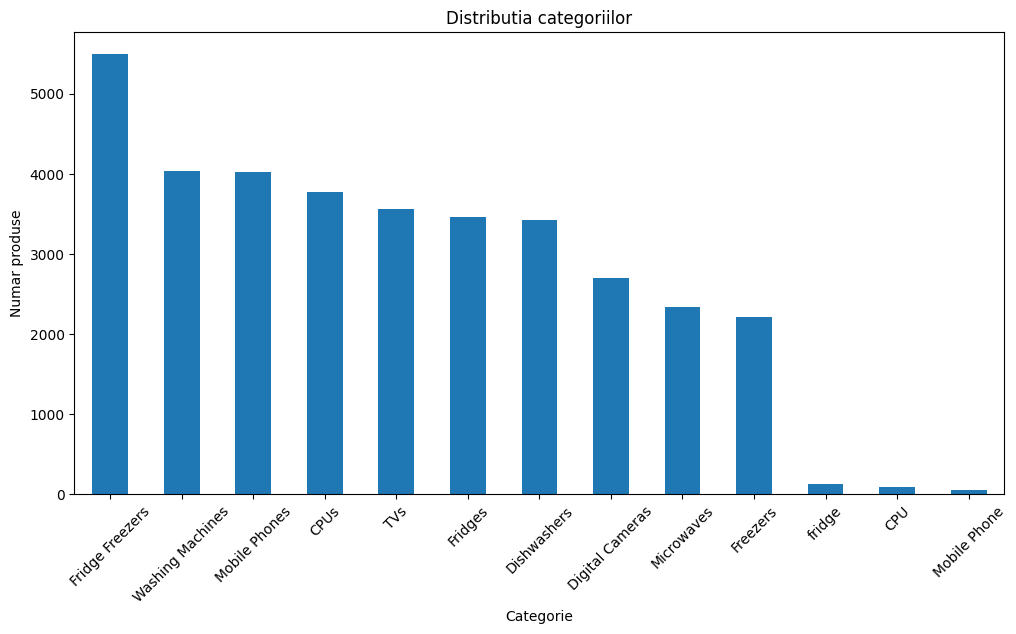

In [5]:
plt.figure(figsize=(12,6))
df["Category Label"].value_counts().plot(kind="bar")
plt.title("Distributia categoriilor")
plt.xlabel("Categorie")
plt.ylabel("Numar produse")
plt.xticks(rotation=45)
plt.show()


# Lungimea titlurilor de produs

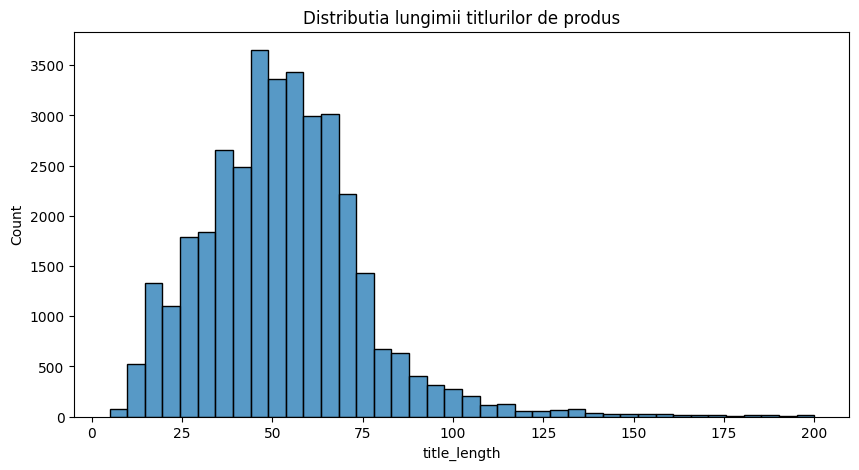

In [6]:
df["title_length"] = df["Product Title"].str.len()

plt.figure(figsize=(10,5))
sns.histplot(df["title_length"], bins=40)
plt.title("Distributia lungimii titlurilor de produs")
plt.show()


# Curatarea textului

In [7]:
df["Product Title"] = df["Product Title"].str.lower()
df = df[["Product Title", "Category Label"]].dropna()

df.head()


,Product Title,Category Label
0,apple iphone 8 plus 64gb silver,Mobile Phones
1,apple iphone 8 plus 64 gb spacegrau,Mobile Phones
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,Mobile Phones
3,apple iphone 8 plus 64gb space grey,Mobile Phones
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,Mobile Phones


# Impartirea datelor in train/test

In [8]:
X = df["Product Title"]
y = df["Category Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Vectorizare TF-IDF

In [9]:
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


# Antrenarea modelului

In [10]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

# Evaluare model 

In [11]:
preds = model.predict(X_test_vec)
print(classification_report(y_test, preds))


                  precision    recall  f1-score   support

             CPU       0.00      0.00      0.00        17
            CPUs       0.98      1.00      0.99       749
 Digital Cameras       0.99      0.99      0.99       538
     Dishwashers       0.93      0.96      0.95       681
        Freezers       0.99      0.93      0.96       440
 Fridge Freezers       0.95      0.94      0.94      1094
         Fridges       0.86      0.92      0.89       687
      Microwaves       0.99      0.96      0.97       466
    Mobile Phone       0.00      0.00      0.00        11
   Mobile Phones       0.96      0.99      0.97       801
             TVs       0.97      0.99      0.98       708
Washing Machines       0.95      0.95      0.95       803
          fridge       0.00      0.00      0.00        25

        accuracy                           0.95      7020
       macro avg       0.74      0.74      0.74      7020
    weighted avg       0.95      0.95      0.95      7020



e:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Matrice de confuzie

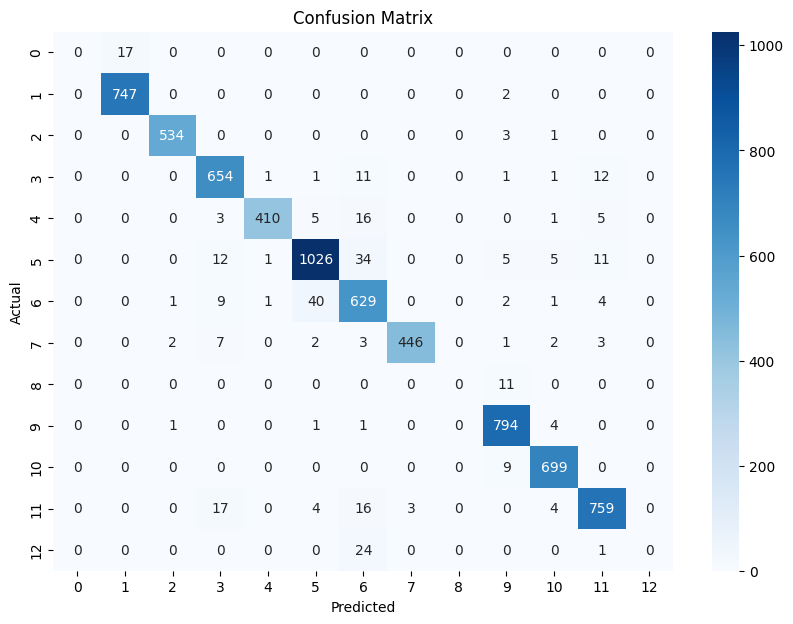

In [12]:
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Test manual de predictie 


In [13]:
def predict_category(title):
    vec = vectorizer.transform([title.lower()])
    return model.predict(vec)[0]

predict_category("iphone 11 128gb black")


'Mobile Phones'